In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
os.getcwd()

'c:\\Users\\Pulki\\OneDrive\\Documents\\WebsiteDataAnalytics'

In [3]:
os.listdir()

['data-export.csv', 'website data anlysis.ipynb']

In [4]:
df = pd.read_csv("data-export.csv")

In [5]:
df.head()

,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


In [6]:
df.columns = df.iloc[0]
df = df.drop(index = 0).reset_index(drop = True)
df.columns = ["Channel group","DateHour","Users","Sessions","Engaged sessions","Average engagement time per user","Engaged sessions per user","Events per session", "Engagement rate","Event count"]
df.head()

,Channel group,DateHour,Users,Sessions,Engaged sessions,Average engagement time per user,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
3,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
4,Organic Social,2024041720,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001


In [7]:
df['DateHour'] = pd.to_datetime(df['DateHour'], format = "%Y%m%d%H")
numeric_df = df.columns.drop(['Channel group',"DateHour"])
df[numeric_df] = df[numeric_df].apply(pd.to_numeric , errors = 'coerce')
df['Hour'] = df['DateHour'].dt.hour
df.head()

,Channel group,DateHour,Users,Sessions,Engaged sessions,Average engagement time per user,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Channel group                     3182 non-null   object        
 1   DateHour                          3182 non-null   datetime64[ns]
 2   Users                             3182 non-null   int64         
 3   Sessions                          3182 non-null   int64         
 4   Engaged sessions                  3182 non-null   int64         
 5   Average engagement time per user  3182 non-null   float64       
 6   Engaged sessions per user         3182 non-null   float64       
 7   Events per session                3182 non-null   float64       
 8   Engagement rate                   3182 non-null   float64       
 9   Event count                       3182 non-null   int64         
 10  Hour                              3182 non-null 

In [9]:
df.describe()

,DateHour,Users,Sessions,Engaged sessions,Average engagement time per user,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
count,3182,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000
mean,2024-04-20 01:17:07.278441216,41.935889,51.192646,28.325581,66.644581,0.606450,4.675969,0.503396,242.272470,11.807040
min,2024-04-06 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2024-04-13 02:15:00,20.000000,24.000000,13.000000,32.103034,0.561404,3.750000,0.442902,103.000000,6.000000
50%,2024-04-20 02:00:00,42.000000,51.000000,27.000000,49.020202,0.666667,4.410256,0.545455,226.000000,12.000000
75%,2024-04-26 22:00:00,60.000000,71.000000,41.000000,71.487069,0.750000,5.217690,0.633333,339.000000,18.000000
max,2024-05-03 23:00:00,237.000000,300.000000,144.000000,4525.000000,2.000000,56.000000,1.000000,1402.000000,23.000000
std,NaN,29.582258,36.919962,20.650569,127.200659,0.264023,2.795228,0.228206,184.440313,6.886686


# Sessions and user trend over time

In [10]:
sns.set_style('whitegrid')

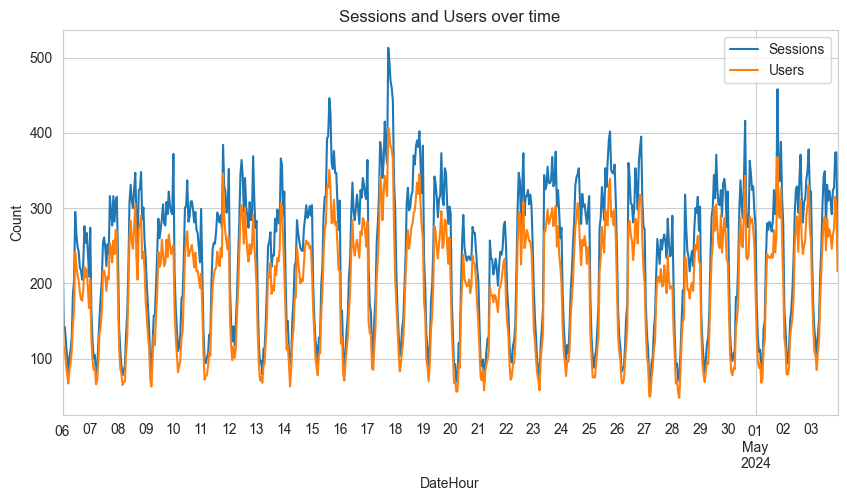

In [11]:
plt.figure(figsize= (10,5))
df.groupby('DateHour')[['Sessions','Users']].sum().plot(ax= plt.gca())
plt.title('Sessions and Users over time')
plt.xlabel('DateHour')
plt.ylabel('Count')
plt.show()

The data shows a strong daily cyclical pattern, indicating user activity varies by time of day. Sessions are consistently higher than users, suggesting repeat visits or multiple sessions per user. There is no clear long-term upward or downward trend, indicating stable traffic. Occasional spikes may indicate campaign-driven traffic. Additionally, sessions and users are highly correlated, moving together over time.

In [12]:
df.head()

,Channel group,DateHour,Users,Sessions,Engaged sessions,Average engagement time per user,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


# Total users by Channel

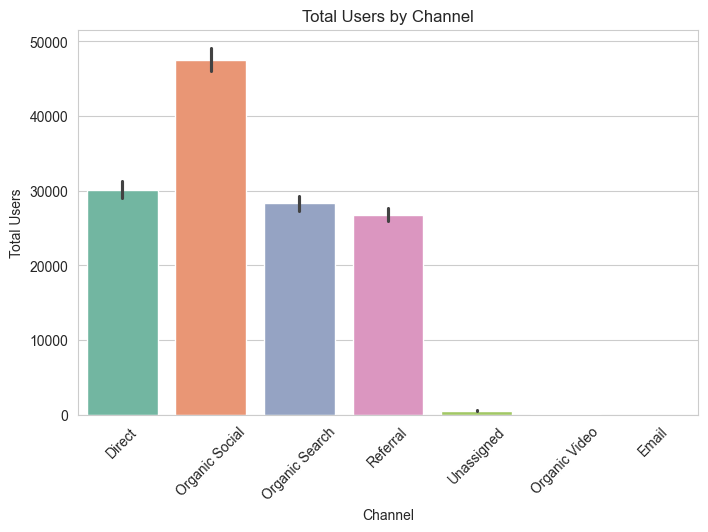

In [13]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x='Channel group',y='Users',estimator=np.sum,palette='Set2',hue='Channel group',legend=False)
plt.title('Total Users by Channel')
plt.xlabel('Channel')
plt.ylabel('Total Users')
plt.xticks(rotation=45)
plt.show()

Organic Social brought the highest number of users, indicating strong performance in social media marketing. To improve underperforming channels, we can replicate successful social media strategies across Email and Organic Video. Additionally, unassigned traffic should be investigated for potential tracking issues.

# Average engagement time by Channel

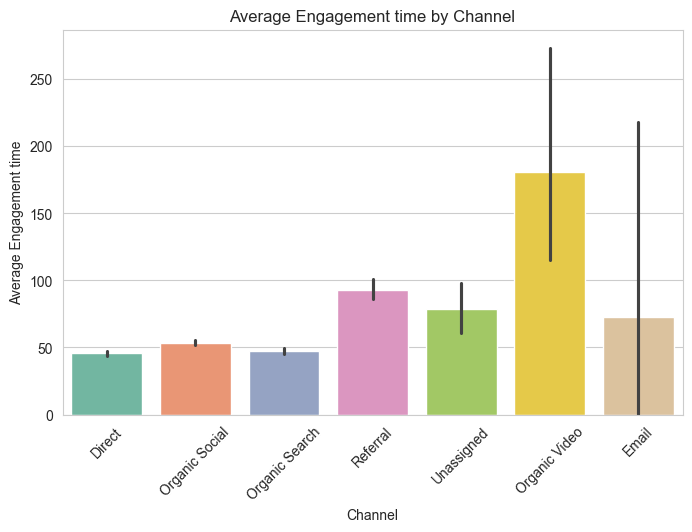

In [14]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x='Channel group',y='Average engagement time per user',estimator=np.average,palette='Set2',hue='Channel group',legend=False)
plt.title('Average Engagement time by Channel')
plt.xlabel('Channel')
plt.ylabel('Average Engagement time')
plt.xticks(rotation=45)
plt.show()

Organic Video has the highest average engagement time, indicating strong content engagement. However, its high variability suggests inconsistent user behavior. Email shows moderate average engagement but very high variability, making it less reliable. Channels like Direct and Organic Social demonstrate moderate but stable engagement.

This suggests that Organic Video content can be optimized to make engagement more consistent, while strategies from high-performing channels like Organic Social can be applied to improve the consistency of Email.

In [15]:
df.head()

,Channel group,DateHour,Users,Sessions,Engaged sessions,Average engagement time per user,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


C:\Users\Pulki\AppData\Local\Temp\ipykernel_4116\1356810922.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='Channel group',y='Engagement rate',palette='Set2')


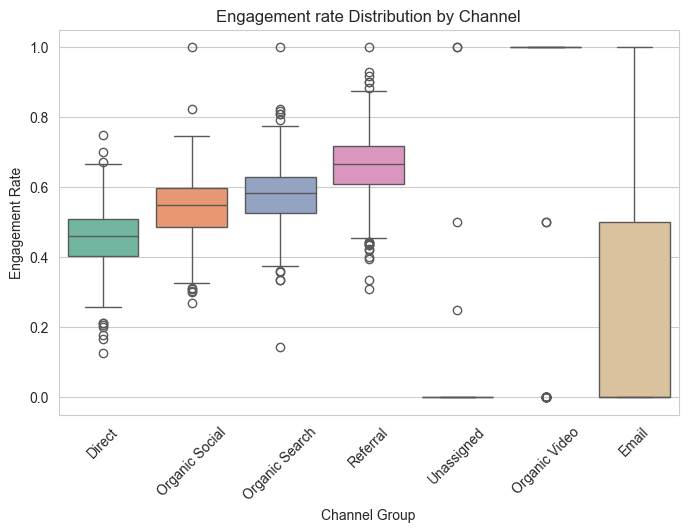

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x='Channel group',y='Engagement rate',palette='Set2')
plt.title('Engagement rate Distribution by Channel')
plt.xlabel('Channel Group')
plt.ylabel('Engagement Rate')
plt.xticks(rotation=45)
plt.show()

Referral shows the highest engagement rate with relatively good consistency. Organic Social and Organic Search also demonstrate strong and stable engagement, while Direct traffic has moderate but fairly consistent engagement.

Email shows lower engagement with very high variability, indicating inconsistent user behavior. Organic Video and Unassigned channels display irregular patterns, possibly due to data issues or small sample sizes.

This suggests focusing on Referral, Organic Search, and Organic Social for high-quality traffic, while optimizing marketing strategies to improve consistency in underperforming channels. Additionally, tracking issues in Unassigned and Organic Video channels should be investigated.

In [17]:
df.head()

,Channel group,DateHour,Users,Sessions,Engaged sessions,Average engagement time per user,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


# Engaged vs Non-engaged Sessions

In [18]:
session_df = df.groupby('Channel group')[['Sessions', 'Engaged sessions']].sum()
session_df['Non_engaged'] = session_df['Sessions'] - session_df['Engaged sessions']
session_df = session_df.reset_index()

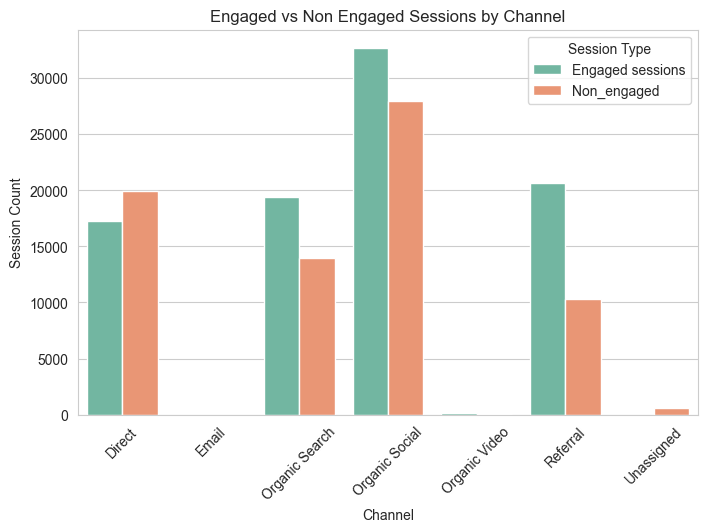

In [55]:
plt.figure(figsize=(8,5))

melted = session_df.melt(
    id_vars='Channel group',
    value_vars=['Engaged sessions', 'Non_engaged'],
    var_name='Session Type',
    value_name='session Count'
)

sns.barplot(data=melted,x='Channel group',y='session Count',hue='Session Type',palette='Set2')

plt.title('Engaged vs Non Engaged Sessions by Channel')
plt.xlabel('Channel')
plt.ylabel('Session Count')
plt.xticks(rotation = 45)
plt.tight_layout
plt.show()

Organic social brought the highest traffic but has a lower engagement efficieny, while referal brought lower but more enganged users. Organic Search performs moderately well showing a room for optimization .Direct Traffic shows a concerning drop in engagement suggest possible expectation mismatch issue. Email, Organic Video, Unassigned show almost no engagement showing possible tracking issue or weaker campaign.



# Channel Trafic by Hour

In [21]:
df.head()

,Channel group,DateHour,Users,Sessions,Engaged sessions,Average engagement time per user,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


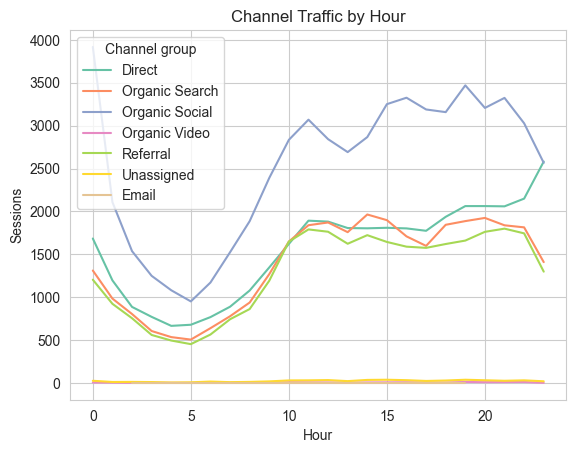

In [56]:
df_hour = df.groupby(['Hour','Channel group'])['Sessions'].sum().reset_index()

sns.lineplot(data = df_hour,x='Hour',y = 'Sessions', hue = 'Channel group',palette='Set2')
plt.title('Channel Traffic by Hour')
plt.xlabel('Hour')
plt.ylabel('Sessions')
plt.show()

Traffic across all channels rises during the day and drops significantly at night. Organic Social drives the highest traffic throughout the day, with a peak in the afternoon and evening, while other channels follow a similar pattern at lower volumes.

Organic Video, Email, and Unassigned remain almost flat. Most channels show peak activity between 10 AM and 3 PM, with a secondary rise in the evening (6 PM to 8 PM). These are the most effective time windows for campaigns.

# Engagement Rate and Traffic Trend

<Axes: xlabel='Engagement rate', ylabel='Sessions'>

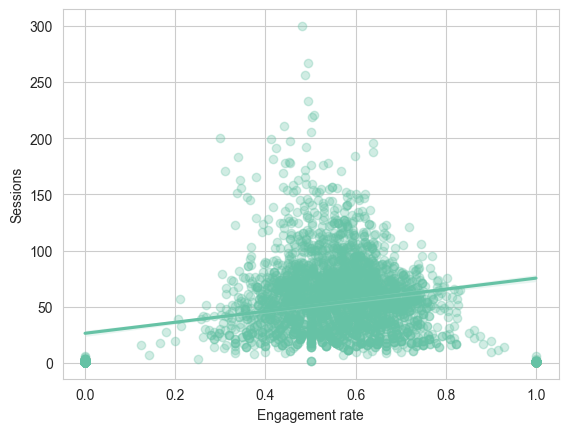

In [65]:
sns.regplot(data=df,x='Engagement rate',y='Sessions',scatter_kws={'alpha':0.3},color="#66c2a5")

Sessions and engagement rate show a very weak positive correlation, with most data points concentrated between 0.4 and 0.7. This indicates that higher traffic does not strongly translate into higher engagement.